# Named Entity Word Clouds

Four sets of circular word clouds — font size ∝ mention frequency:

1. **Per news source** — AD, GA, NRC, NU.nl, Parool, TG, TR, VK  
2. **Per meta-topic** — 17 shared meta-topic categories  
3. **Per Tweede Kamer document type** — beleidsnota, plenair verslag, vergaderstuk  
4. **Per talkshow programme** — 9 Dutch talk shows  

Entity type is selectable via `ENTITY_TYPE` (`PER`, `ORG`, `LOC`, or `ALL`).


In [28]:
import pathlib

HERE = pathlib.Path(".")

# ── Input files (relative to this notebook) ──────────────────────────────────
SOURCE_NODES_CSV   = HERE / "source_entity_nodes.csv"
SOURCE_EDGES_CSV   = HERE / "source_entity_edges.csv"
META_NODES_CSV     = HERE / "metatopic_entity_nodes.csv"
META_EDGES_CSV     = HERE / "metatopic_entity_edges.csv"

# ── Filter ────────────────────────────────────────────────────────────────────
# "PER"  → persons only
# "ORG"  → organisations only
# "LOC"  → locations only
# "ALL"  → all entity types
ENTITY_TYPE = "PER"

# Top N entities shown per cloud (keeps clouds readable)
TOP_N = 50

# ── Output ────────────────────────────────────────────────────────────────────
OUT_SOURCE = HERE / f"wordclouds_per_source_{ENTITY_TYPE.lower()}.png"
OUT_META   = HERE / f"wordclouds_per_metatopic_{ENTITY_TYPE.lower()}.png"
FIG_DPI    = 200

# ── Appearance ────────────────────────────────────────────────────────────────
# Neutral greyscale base; each source gets a subtle tint (see TINTS below)
BG_COLOR     = "white"
MIN_FONT     = 9
MAX_FONT     = 90


In [29]:
import warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image
from wordcloud import WordCloud

warnings.filterwarnings("ignore")


## Step 1 — Load and prepare data

In [30]:
# ── Helpers ───────────────────────────────────────────────────────────────────

def circular_mask(size=600):
    """Binary circular mask (True inside circle) for WordCloud."""
    y, x = np.ogrid[:size, :size]
    cx, cy = size / 2, size / 2
    mask = (x - cx)**2 + (y - cy)**2 > (size / 2 - 2)**2
    arr = np.zeros((size, size), dtype=np.uint8)
    arr[mask] = 255          # WordCloud: 255 = background (outside cloud)
    return arr


def load_graph(nodes_csv, edges_csv, group_col, group_type):
    """
    Load a Gephi bipartite graph (group nodes + entity nodes) and return
    a DataFrame with columns [group, entity, entity_type, count].

    Weight in the edges is a proportion (mentions / group_total); we
    recover an approximate integer count by multiplying by the group size.
    """
    nodes = pd.read_csv(nodes_csv)
    edges = pd.read_csv(edges_csv)

    # Split into group nodes and entity nodes
    grp_nodes = (nodes[nodes["node_type"] == group_type]
                 [["Id", "Label", "size"]]
                 .rename(columns={"Id": "grp_id", "Label": "group", "size": "grp_total"}))

    ent_nodes = (nodes[nodes["node_type"] == "entity"]
                 [["Id", "Label", "entity_type"]]
                 .rename(columns={"Id": "ent_id", "Label": "entity"}))

    # Edges: Source = group, Target = entity (confirmed from data)
    df = (edges
          .merge(grp_nodes, left_on="Source", right_on="grp_id")
          .merge(ent_nodes, left_on="Target",  right_on="ent_id")
          [["group", "grp_total", "entity", "entity_type", "Weight"]])

    df["count"] = (df["Weight"] * df["grp_total"]).round().astype(int)
    df = df[df["count"] > 0]
    return df[["group", "entity", "entity_type", "count"]]


# ── Load ──────────────────────────────────────────────────────────────────────
src_df  = load_graph(SOURCE_NODES_CSV, SOURCE_EDGES_CSV,
                     group_col="source", group_type="news")
meta_df = load_graph(META_NODES_CSV,   META_EDGES_CSV,
                     group_col="metatopic", group_type="metatopic")

# ── Filter by entity type ─────────────────────────────────────────────────────
def filter_type(df, etype):
    if etype == "ALL":
        return df
    return df[df["entity_type"] == etype].copy()

src_per   = filter_type(src_df,  ENTITY_TYPE)
meta_per  = filter_type(meta_df, ENTITY_TYPE)

# Drop UNKNOWN meta-topic
meta_per = meta_per[meta_per["group"] != "UNKNOWN"]

print(f"Source data:    {len(src_per):,} rows across {src_per['group'].nunique()} sources")
print(f"Meta-topic data:{len(meta_per):,} rows across {meta_per['group'].nunique()} meta-topics")
print(f"\nSources:  {sorted(src_per['group'].unique())}")
print(f"\nMeta-topics:")
for m in sorted(meta_per['group'].unique()):
    n = len(meta_per[meta_per['group'] == m])
    print(f"  {m}  ({n} entities)")


Source data:    51,220 rows across 8 sources
Meta-topic data:55,793 rows across 17 meta-topics

Sources:  ['AD', 'GA', 'NRC', 'NU.nl', 'Parool', 'TG', 'TR', 'VK']

Meta-topics:
  AI APPLICATION IN INDUSTRIES  (1843 entities)
  AI FOR SECURITY  (1225 entities)
  AI INFRASTRUCTURE & CHIP INDUSTRY  (1354 entities)
  AI RISKS & ETHICS  (2802 entities)
  AI WARFARE & MILIRTARY CONFLICTS  (1725 entities)
  BUSINESS & FINANCE  (4786 entities)
  CONSUMER TECH  & PRODUCTS  (4340 entities)
  EDUCATION  (1678 entities)
  ENVIRONMENT  (1783 entities)
  GEOPOLITICS  (765 entities)
  LABOR  (813 entities)
  MEDIA, ARTS, CULTURE & SPORTS  (12340 entities)
  POLITICS & LAW  (3848 entities)
  SCIENCE & HEALTH  (3530 entities)
  SOCIAL MEDIA  (4208 entities)
  SOCIETY  (4025 entities)
  TECH & AI DEVELOPMENT  (4728 entities)


## Step 2 — Word clouds per source

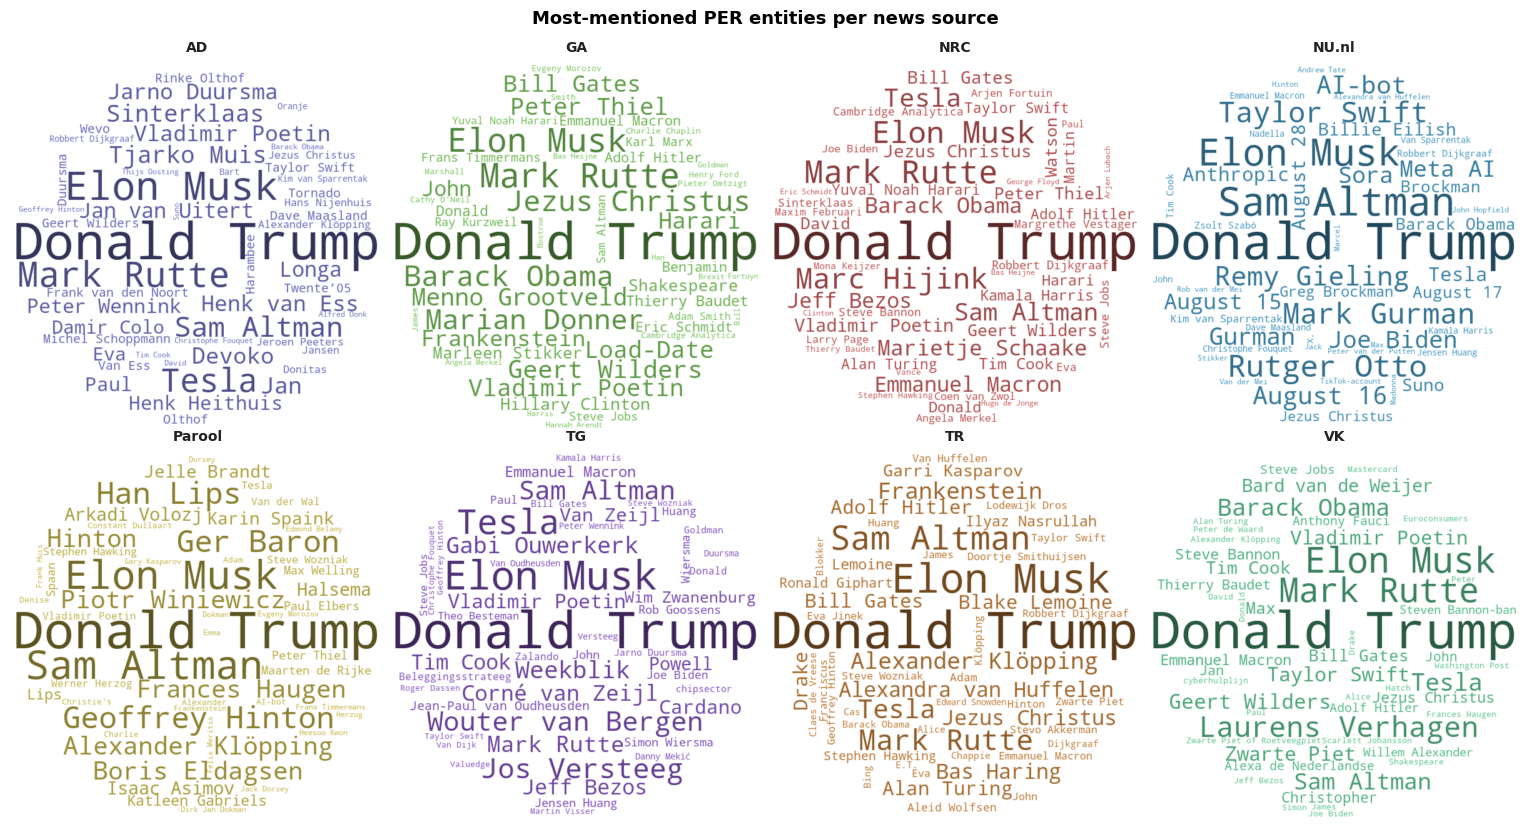

Saved → wordclouds_per_source_per.png


In [31]:
# Subtle per-source tints (HSL-style; colour-blind safe, print-friendly)
# Sources are sorted alphabetically so the mapping is deterministic
SOURCE_TINTS = {
    "AD":     "#1a1a2e",   # very dark navy
    "GA":     "#2d4a22",   # dark green
    "NRC":    "#3b1a1a",   # dark maroon
    "NU.nl":  "#1a3a4a",   # dark teal
    "Parool": "#2e2a10",   # dark olive
    "TG":     "#2a1a3e",   # dark purple
    "TR":     "#3a2510",   # dark brown
    "VK":     "#1a3a2a",   # dark forest
}
DEFAULT_TINT = "#1a1a1a"


def make_cloud(freq_dict, mask, color_func=None, bg=BG_COLOR):
    """Build a WordCloud from a {word: count} dict."""
    wc = WordCloud(
        background_color=bg,
        mask=mask,
        max_words=TOP_N,
        min_font_size=MIN_FONT,
        max_font_size=MAX_FONT,
        prefer_horizontal=0.85,
        color_func=color_func,
        collocations=False,
        random_state=42,
    )
    wc.generate_from_frequencies(freq_dict)
    return wc


def tint_color_func(tint_hex):
    """
    Return a WordCloud color_func that uses the tint colour with varying
    lightness so the cloud has depth while staying colour-blind safe.
    """
    r, g, b = mcolors.to_rgb(tint_hex)
    h, s, v = mcolors.rgb_to_hsv((r, g, b))

    def _fn(word, font_size, position, orientation, random_state=None, **kw):
        # Most-frequent words are dark; rare words lighter
        light = 0.15 + 0.55 * (1 - font_size / MAX_FONT)
        rgb = mcolors.hsv_to_rgb((h, max(0.2, s), light + 0.15))
        return tuple(int(c * 255) for c in rgb)
    return _fn


def plot_wordclouds(grouped_df, group_col, tint_map, ncols, title, out_path):
    """
    Render one circular word cloud per group, arranged in a grid.

    grouped_df : DataFrame with columns [group_col, 'entity', 'count']
    tint_map   : dict mapping group label -> hex colour (for tinting)
    ncols      : number of columns in the grid
    """
    groups  = sorted(grouped_df[group_col].unique())
    ngroups = len(groups)
    nrows   = math.ceil(ngroups / ncols)
    mask    = circular_mask(600)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 3.8, nrows * 3.8 + 0.6),
        facecolor="white",
    )
    axes_flat = np.array(axes).flatten()

    for ax in axes_flat:
        ax.set_visible(False)

    for i, group in enumerate(groups):
        ax = axes_flat[i]
        ax.set_visible(True)

        subset    = grouped_df[grouped_df[group_col] == group]
        freq_dict = dict(zip(subset["entity"], subset["count"]))

        if not freq_dict:
            ax.set_title(group, fontsize=9, pad=4)
            ax.axis("off")
            continue

        tint   = tint_map.get(group, DEFAULT_TINT)
        cfunc  = tint_color_func(tint)
        wc     = make_cloud(freq_dict, mask.copy(), color_func=cfunc)

        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(group, fontsize=10, fontweight="bold", pad=5,
                     color="#222222")
        ax.axis("off")

    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    fig.tight_layout(pad=0.3)
    fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight",
                facecolor="white")
    plt.show()
    print(f"Saved → {out_path}")


# Build a neutral tint map for sources
src_tint_map = {g: SOURCE_TINTS.get(g, DEFAULT_TINT) for g in src_per["group"].unique()}

plot_wordclouds(
    src_per, "group",
    tint_map=src_tint_map,
    ncols=4,
    title=f"Most-mentioned {ENTITY_TYPE} entities per news source",
    out_path=OUT_SOURCE,
)


## Step 3 — Word clouds per meta-topic

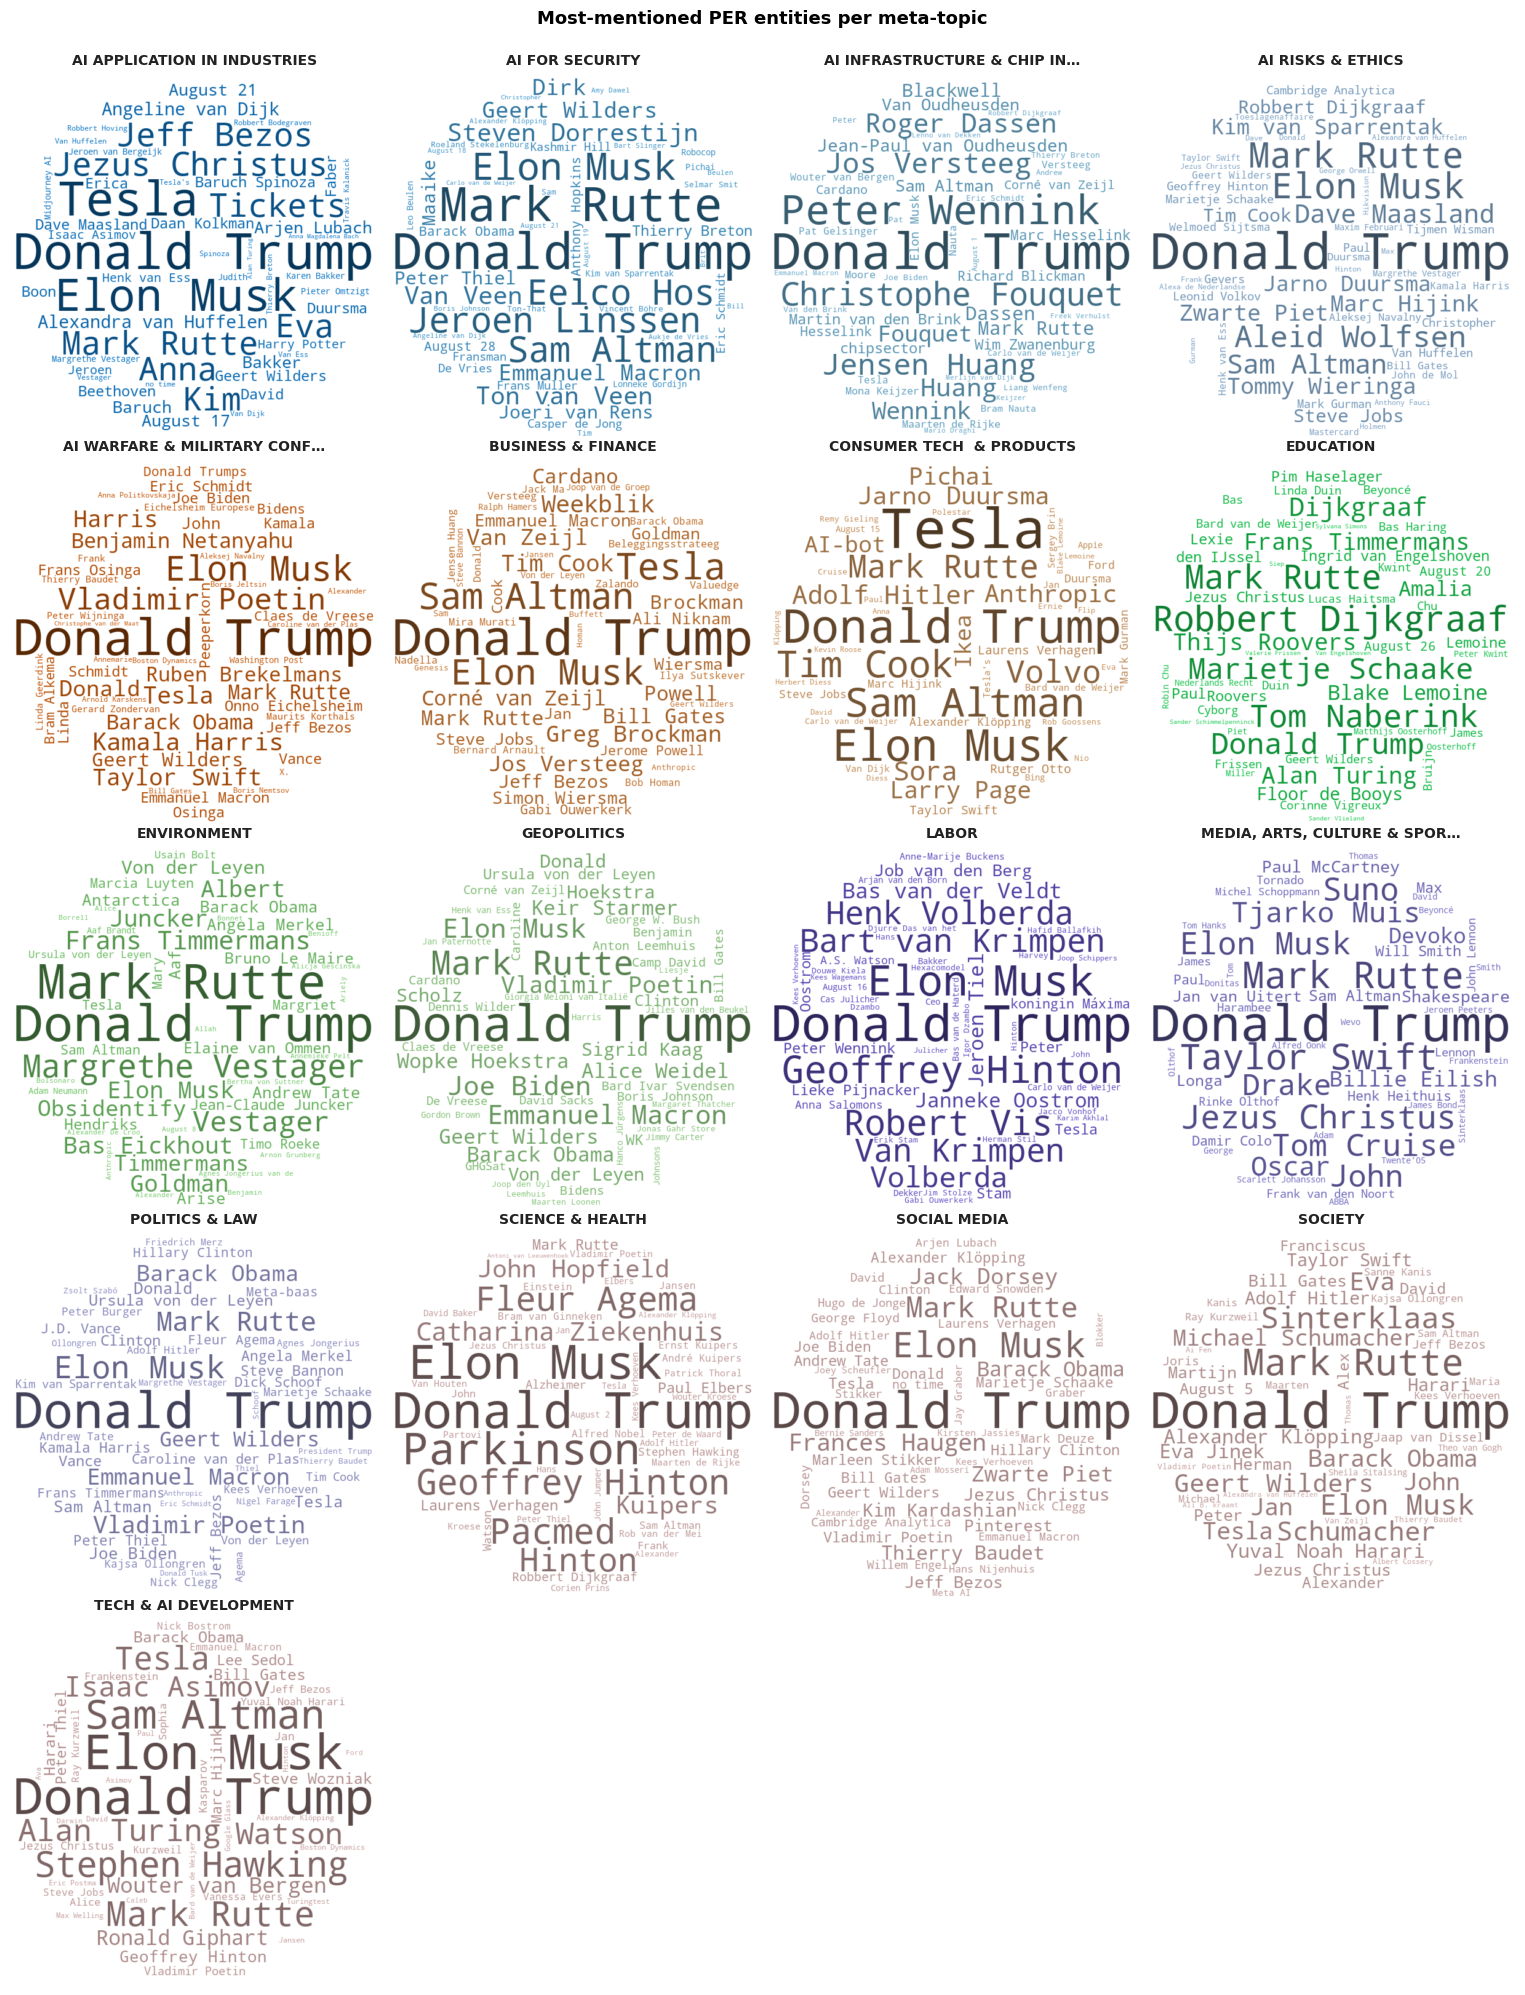

Saved → wordclouds_per_metatopic_per.png


In [32]:
# Assign a distinct tint to each meta-topic using a perceptually uniform palette
# (tab20c has 20 distinct colours — enough for 17 meta-topics)
import matplotlib.cm as mcm

def build_meta_tints(meta_topics):
    cmap  = mcm.get_cmap("tab20c", len(meta_topics))
    tints = {}
    for i, m in enumerate(sorted(meta_topics)):
        r, g, b, _ = cmap(i)
        # Darken the tab colour so it reads well on white
        h, s, v = mcolors.rgb_to_hsv((r, g, b))
        dark_rgb = mcolors.hsv_to_rgb((h, min(1.0, s + 0.2), max(0.2, v - 0.35)))
        tints[m] = mcolors.to_hex(dark_rgb)
    return tints

meta_tints = build_meta_tints(meta_per["group"].unique())

# Abbreviate long meta-topic names for subplot titles
def abbrev(label, maxlen=28):
    return label if len(label) <= maxlen else label[:maxlen-1].rstrip() + "…"

meta_per_disp = meta_per.copy()
meta_per_disp["group"] = meta_per_disp["group"].apply(abbrev)
meta_tints_disp = {abbrev(k): v for k, v in meta_tints.items()}

plot_wordclouds(
    meta_per_disp, "group",
    tint_map=meta_tints_disp,
    ncols=4,
    title=f"Most-mentioned {ENTITY_TYPE} entities per meta-topic",
    out_path=OUT_META,
)


## Step 4 — Summary: top entities per group

In [33]:
def top_entities_table(df, group_col, n=5):
    """Print the top-n entities for every group in a compact table."""
    for group in sorted(df[group_col].unique()):
        top = (df[df[group_col] == group]
               .nlargest(n, "count")[["entity", "count"]]
               .reset_index(drop=True))
        top.index += 1
        print(f"{'─' * 48}")
        print(f"  {group}")
        print(top.to_string(index=True))
    print(f"{'─' * 48}")


print("=" * 48)
print(f"TOP ENTITIES PER SOURCE  (type={ENTITY_TYPE})")
print("=" * 48)
top_entities_table(src_per, "group", n=5)

print()
print("=" * 48)
print(f"TOP ENTITIES PER META-TOPIC  (type={ENTITY_TYPE})")
print("=" * 48)
top_entities_table(meta_per, "group", n=5)


TOP ENTITIES PER SOURCE  (type=PER)
────────────────────────────────────────────────
  AD
         entity  count
1  Donald Trump    164
2     Elon Musk     92
3    Mark Rutte     71
4         Tesla     60
5    Sam Altman     43
────────────────────────────────────────────────
  GA
           entity  count
1    Donald Trump     88
2      Mark Rutte     29
3       Elon Musk     28
4    Barack Obama     21
5  Jezus Christus     21
────────────────────────────────────────────────
  NRC
         entity  count
1  Donald Trump    326
2    Mark Rutte     82
3     Elon Musk     75
4   Marc Hijink     66
5         Tesla     52
────────────────────────────────────────────────
  NU.nl
         entity  count
1  Donald Trump     73
2    Sam Altman     40
3     Elon Musk     36
4   Rutger Otto     23
5   Mark Gurman     20
────────────────────────────────────────────────
  Parool
            entity  count
1     Donald Trump     16
2        Elon Musk      9
3       Sam Altman      9
4  Geoffrey Hinton

---
## Step 5 — Word clouds per Tweede Kamer document type

Source: `tweede_kamer/analysis/Tweede_Kamer_with_NER.csv`
Groups: **beleidsnota**, **plenair verslag**, **vergaderstuk**

The NER columns (`persons`, `orgs`, `countries`) are stored as Python list
strings and are parsed with `ast.literal_eval`.  The `ENTITY_TYPE` parameter
maps to the corresponding column (`PER→persons`, `ORG→orgs`, `LOC→countries`).


In [34]:
import ast

TK_CSV = HERE / "../../tweede_kamer/analysis/Tweede_Kamer_with_NER.csv"

# Map the shared ENTITY_TYPE flag to the column name used in this dataset
TK_COL_MAP = {"PER": "persons", "ORG": "orgs", "LOC": "countries", "ALL": None}
OUT_TK = HERE / f"wordclouds_tk_types_{ENTITY_TYPE.lower()}.png"

# ── Tints for document types ──────────────────────────────────────────────────
TK_TINTS = {
    "beleidsnota":    "#1a2e4a",   # dark blue  (policy documents)
    "plenair verslag":"#2e1a1a",   # dark red   (parliamentary debates)
    "vergaderstuk":   "#1a2e1a",   # dark green (meeting documents)
}

def parse_list_col(series):
    """Parse a column of string-encoded Python lists, return lists."""
    def _safe(v):
        try:
            return ast.literal_eval(v)
        except Exception:
            return []
    return series.fillna("[]").apply(_safe)


def load_ner_from_doc_csv(csv_path, group_col, entity_col_or_cols):
    """
    Load a document-level CSV where NER results are stored as list columns.

    Returns a DataFrame [group, entity, count] suitable for plot_wordclouds().

    entity_col_or_cols : a single column name, or a list of columns (for ALL).
    """
    df = pd.read_csv(csv_path)

    if isinstance(entity_col_or_cols, str):
        cols = [entity_col_or_cols]
    else:
        cols = entity_col_or_cols

    rows = []
    for col in cols:
        if col not in df.columns:
            continue
        df[f"_{col}_parsed"] = parse_list_col(df[col])
        exploded = (
            df[[group_col, f"_{col}_parsed"]]
            .explode(f"_{col}_parsed")
            .rename(columns={f"_{col}_parsed": "entity"})
        )
        rows.append(exploded)

    combined = pd.concat(rows, ignore_index=True)
    combined["entity"] = combined["entity"].astype(str).str.strip()
    # Drop very short strings (noise from OCR / NER errors)
    combined = combined[combined["entity"].str.len() > 2]

    counts = (combined
              .groupby([group_col, "entity"])
              .size()
              .reset_index(name="count")
              .rename(columns={group_col: "group"}))
    return counts


# Determine which column(s) to use
if ENTITY_TYPE == "ALL":
    tk_cols = ["persons", "orgs", "countries"]
else:
    tk_cols = TK_COL_MAP[ENTITY_TYPE]

tk_counts = load_ner_from_doc_csv(TK_CSV, group_col="type", entity_col_or_cols=tk_cols)

print(f"Tweede Kamer — {ENTITY_TYPE} entities per document type:")
for grp in sorted(tk_counts["group"].unique()):
    n = tk_counts[tk_counts["group"] == grp]["count"].sum()
    print(f"  {grp}: {n:,} total entity mentions")


Tweede Kamer — PER entities per document type:
  beleidsnota: 1,532 total entity mentions
  plenair verslag: 2,249 total entity mentions
  vergaderstuk: 162 total entity mentions


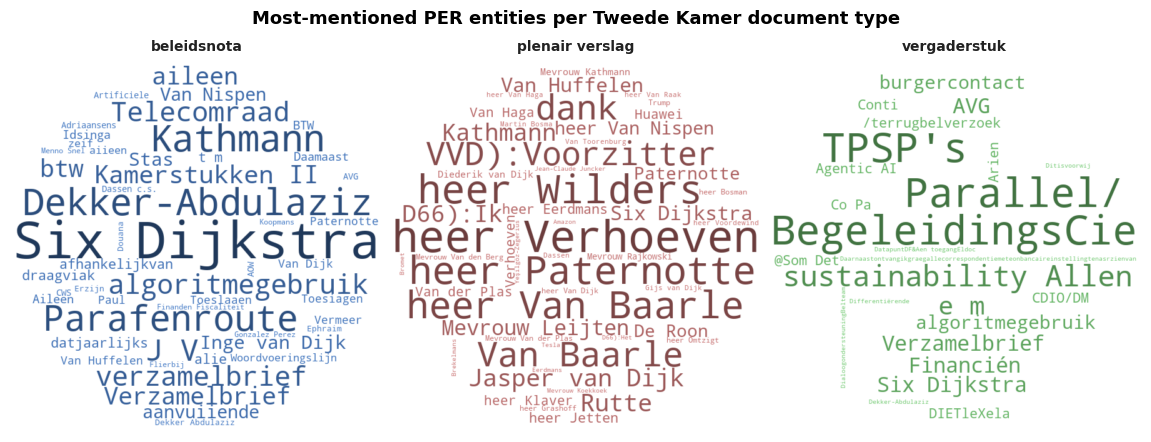

Saved → wordclouds_tk_types_per.png


In [35]:
plot_wordclouds(
    tk_counts, "group",
    tint_map=TK_TINTS,
    ncols=3,
    title=f"Most-mentioned {ENTITY_TYPE} entities per Tweede Kamer document type",
    out_path=OUT_TK,
)


## Step 6 — Word clouds per talkshow program

Source: `subtitles/analysis/subs_with_NER.csv`
Groups: one cloud per talk-show programme.


In [36]:
SUBS_CSV = HERE / "../../subtitles/analysis/subs_with_NER.csv"
OUT_SUBS = HERE / f"wordclouds_talkshows_{ENTITY_TYPE.lower()}.png"

# Pretty programme names for titles
PROG_LABELS = {
    "goedemorgen nederland": "Goedemorgen Nederland",
    "de wereld draait door":  "DWDD",
    "eva":                    "Eva",
    "jinek":                  "Jinek",
    "bar laat":               "Bar Laat",
    "pauw":                   "Pauw",
    "café kockelmann":        "Café Kockelmann",
    "de vooravond":           "De Vooravond",
    "m":                      "M",
}

# Assign a tint per programme (uses the same tab20c palette as meta-topics)
def build_prog_tints(programs):
    cmap = mcm.get_cmap("tab20b", len(programs))
    tints = {}
    for i, p in enumerate(sorted(programs)):
        r, g, b, _ = cmap(i)
        h, s, v = mcolors.rgb_to_hsv((r, g, b))
        dark = mcolors.hsv_to_rgb((h, min(1.0, s + 0.2), max(0.2, v - 0.3)))
        tints[PROG_LABELS.get(p, p.title())] = mcolors.to_hex(dark)
    return tints


# Load and rename groups to display labels
subs_raw = load_ner_from_doc_csv(
    SUBS_CSV, group_col="program",
    entity_col_or_cols=(tk_cols if ENTITY_TYPE == "ALL" else TK_COL_MAP[ENTITY_TYPE]),
)
subs_raw["group"] = subs_raw["group"].map(lambda p: PROG_LABELS.get(p, p.title()))

prog_tints = build_prog_tints(PROG_LABELS.keys())

print(f"Talkshows — {ENTITY_TYPE} entities per programme:")
for grp in sorted(subs_raw["group"].unique()):
    n = subs_raw[subs_raw["group"] == grp]["count"].sum()
    print(f"  {grp}: {n:,} total entity mentions")


Talkshows — PER entities per programme:
  Bar Laat: 87 total entity mentions
  Café Kockelmann: 46 total entity mentions
  DWDD: 337 total entity mentions
  De Vooravond: 19 total entity mentions
  Eva: 212 total entity mentions
  Goedemorgen Nederland: 687 total entity mentions
  Jinek: 76 total entity mentions
  M: 14 total entity mentions
  Pauw: 80 total entity mentions


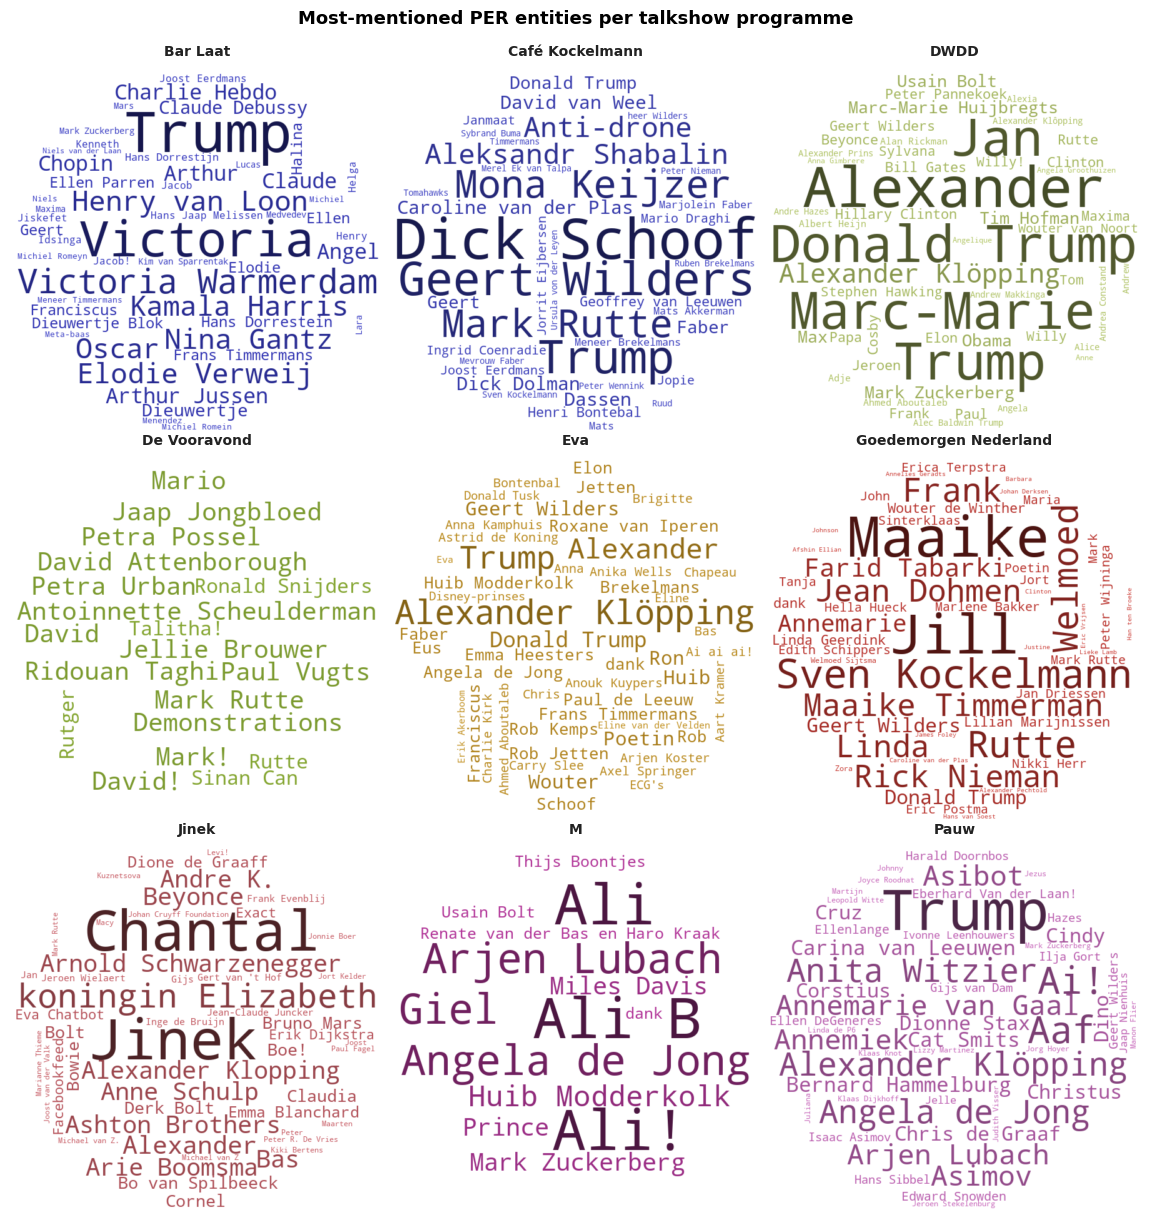

Saved → wordclouds_talkshows_per.png


In [37]:
plot_wordclouds(
    subs_raw, "group",
    tint_map=prog_tints,
    ncols=3,
    title=f"Most-mentioned {ENTITY_TYPE} entities per talkshow programme",
    out_path=OUT_SUBS,
)


## Step 7 — Summary: top entities for TK types and talkshows

In [38]:
print("=" * 52)
print(f"TOP ENTITIES PER TK DOCUMENT TYPE  (type={ENTITY_TYPE})")
print("=" * 52)
top_entities_table(tk_counts, "group", n=8)

print()
print("=" * 52)
print(f"TOP ENTITIES PER TALKSHOW  (type={ENTITY_TYPE})")
print("=" * 52)
top_entities_table(subs_raw, "group", n=8)


TOP ENTITIES PER TK DOCUMENT TYPE  (type=PER)
────────────────────────────────────────────────
  beleidsnota
             entity  count
1      Six Dijkstra     17
2  Dekker-Abdulaziz     12
3          Kathmann     12
4      Parafenroute     11
5               J V      7
6       Telecomraad      6
7  algoritmegebruik      6
8     verzamelbrief      6
────────────────────────────────────────────────
  plenair verslag
            entity  count
1   heer Verhoeven     30
2     heer Wilders     24
3  heer Paternotte     23
4  heer Van Baarle     23
5       Van Baarle     19
6             dank     19
7  VVD):Voorzitter     17
8  Jasper van Dijk     16
────────────────────────────────────────────────
  vergaderstuk
                 entity  count
1       BegeleidingsCie      4
2             Parallel/      4
3                TPSP's      4
4  sustainability Allen      4
5                   e m      3
6                   AVG      2
7             Financién      2
8          Six Dijkstra      2
────

---
## Step 5 — Word clouds per Tweede Kamer document type

Source: `tweede_kamer/analysis/Tweede_Kamer_with_NER.csv`
Groups: **beleidsnota**, **plenair verslag**, **vergaderstuk**

The NER columns (`persons`, `orgs`, `countries`) are stored as Python list
strings and are parsed with `ast.literal_eval`.  The `ENTITY_TYPE` parameter
maps to the corresponding column (`PER→persons`, `ORG→orgs`, `LOC→countries`).


In [39]:
import ast

TK_CSV = HERE / "../../tweede_kamer/analysis/Tweede_Kamer_with_NER.csv"

# Map the shared ENTITY_TYPE flag to the column name used in this dataset
TK_COL_MAP = {"PER": "persons", "ORG": "orgs", "LOC": "countries", "ALL": None}
OUT_TK = HERE / f"wordclouds_tk_types_{ENTITY_TYPE.lower()}.png"

# ── Tints for document types ──────────────────────────────────────────────────
TK_TINTS = {
    "beleidsnota":    "#1a2e4a",   # dark blue  (policy documents)
    "plenair verslag":"#2e1a1a",   # dark red   (parliamentary debates)
    "vergaderstuk":   "#1a2e1a",   # dark green (meeting documents)
}

def parse_list_col(series):
    """Parse a column of string-encoded Python lists, return lists."""
    def _safe(v):
        try:
            return ast.literal_eval(v)
        except Exception:
            return []
    return series.fillna("[]").apply(_safe)


def load_ner_from_doc_csv(csv_path, group_col, entity_col_or_cols):
    """
    Load a document-level CSV where NER results are stored as list columns.

    Returns a DataFrame [group, entity, count] suitable for plot_wordclouds().

    entity_col_or_cols : a single column name, or a list of columns (for ALL).
    """
    df = pd.read_csv(csv_path)

    if isinstance(entity_col_or_cols, str):
        cols = [entity_col_or_cols]
    else:
        cols = entity_col_or_cols

    rows = []
    for col in cols:
        if col not in df.columns:
            continue
        df[f"_{col}_parsed"] = parse_list_col(df[col])
        exploded = (
            df[[group_col, f"_{col}_parsed"]]
            .explode(f"_{col}_parsed")
            .rename(columns={f"_{col}_parsed": "entity"})
        )
        rows.append(exploded)

    combined = pd.concat(rows, ignore_index=True)
    combined["entity"] = combined["entity"].astype(str).str.strip()
    # Drop very short strings (noise from OCR / NER errors)
    combined = combined[combined["entity"].str.len() > 2]

    counts = (combined
              .groupby([group_col, "entity"])
              .size()
              .reset_index(name="count")
              .rename(columns={group_col: "group"}))
    return counts


# Determine which column(s) to use
if ENTITY_TYPE == "ALL":
    tk_cols = ["persons", "orgs", "countries"]
else:
    tk_cols = TK_COL_MAP[ENTITY_TYPE]

tk_counts = load_ner_from_doc_csv(TK_CSV, group_col="type", entity_col_or_cols=tk_cols)

print(f"Tweede Kamer — {ENTITY_TYPE} entities per document type:")
for grp in sorted(tk_counts["group"].unique()):
    n = tk_counts[tk_counts["group"] == grp]["count"].sum()
    print(f"  {grp}: {n:,} total entity mentions")


Tweede Kamer — PER entities per document type:
  beleidsnota: 1,532 total entity mentions
  plenair verslag: 2,249 total entity mentions
  vergaderstuk: 162 total entity mentions


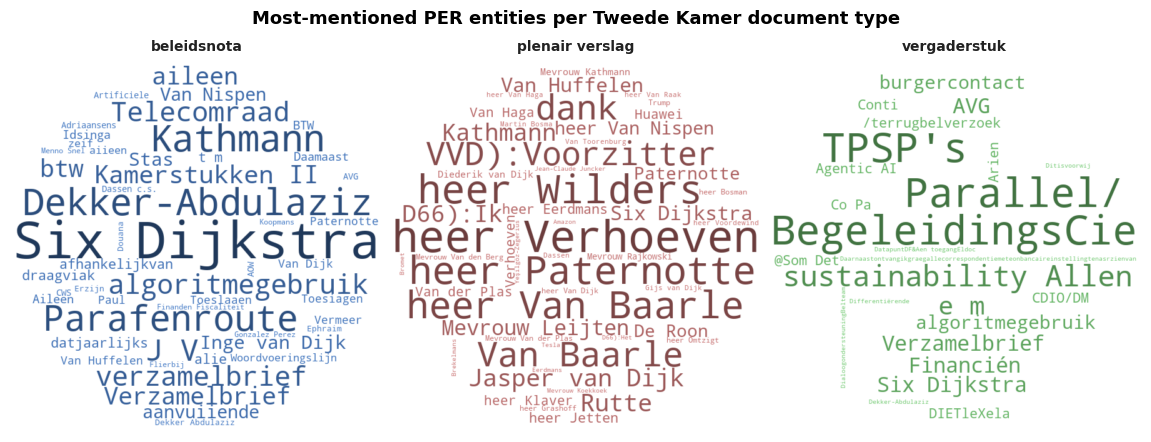

Saved → wordclouds_tk_types_per.png


In [40]:
plot_wordclouds(
    tk_counts, "group",
    tint_map=TK_TINTS,
    ncols=3,
    title=f"Most-mentioned {ENTITY_TYPE} entities per Tweede Kamer document type",
    out_path=OUT_TK,
)


## Step 6 — Word clouds per talkshow program

Source: `subtitles/analysis/subs_with_NER.csv`
Groups: one cloud per talk-show programme.


In [41]:
SUBS_CSV = HERE / "../../subtitles/analysis/subs_with_NER.csv"
OUT_SUBS = HERE / f"wordclouds_talkshows_{ENTITY_TYPE.lower()}.png"

# Pretty programme names for titles
PROG_LABELS = {
    "goedemorgen nederland": "Goedemorgen Nederland",
    "de wereld draait door":  "DWDD",
    "eva":                    "Eva",
    "jinek":                  "Jinek",
    "bar laat":               "Bar Laat",
    "pauw":                   "Pauw",
    "café kockelmann":        "Café Kockelmann",
    "de vooravond":           "De Vooravond",
    "m":                      "M",
}

# Assign a tint per programme (uses the same tab20c palette as meta-topics)
def build_prog_tints(programs):
    cmap = mcm.get_cmap("tab20b", len(programs))
    tints = {}
    for i, p in enumerate(sorted(programs)):
        r, g, b, _ = cmap(i)
        h, s, v = mcolors.rgb_to_hsv((r, g, b))
        dark = mcolors.hsv_to_rgb((h, min(1.0, s + 0.2), max(0.2, v - 0.3)))
        tints[PROG_LABELS.get(p, p.title())] = mcolors.to_hex(dark)
    return tints


# Load and rename groups to display labels
subs_raw = load_ner_from_doc_csv(
    SUBS_CSV, group_col="program",
    entity_col_or_cols=(tk_cols if ENTITY_TYPE == "ALL" else TK_COL_MAP[ENTITY_TYPE]),
)
subs_raw["group"] = subs_raw["group"].map(lambda p: PROG_LABELS.get(p, p.title()))

prog_tints = build_prog_tints(PROG_LABELS.keys())

print(f"Talkshows — {ENTITY_TYPE} entities per programme:")
for grp in sorted(subs_raw["group"].unique()):
    n = subs_raw[subs_raw["group"] == grp]["count"].sum()
    print(f"  {grp}: {n:,} total entity mentions")


Talkshows — PER entities per programme:
  Bar Laat: 87 total entity mentions
  Café Kockelmann: 46 total entity mentions
  DWDD: 337 total entity mentions
  De Vooravond: 19 total entity mentions
  Eva: 212 total entity mentions
  Goedemorgen Nederland: 687 total entity mentions
  Jinek: 76 total entity mentions
  M: 14 total entity mentions
  Pauw: 80 total entity mentions


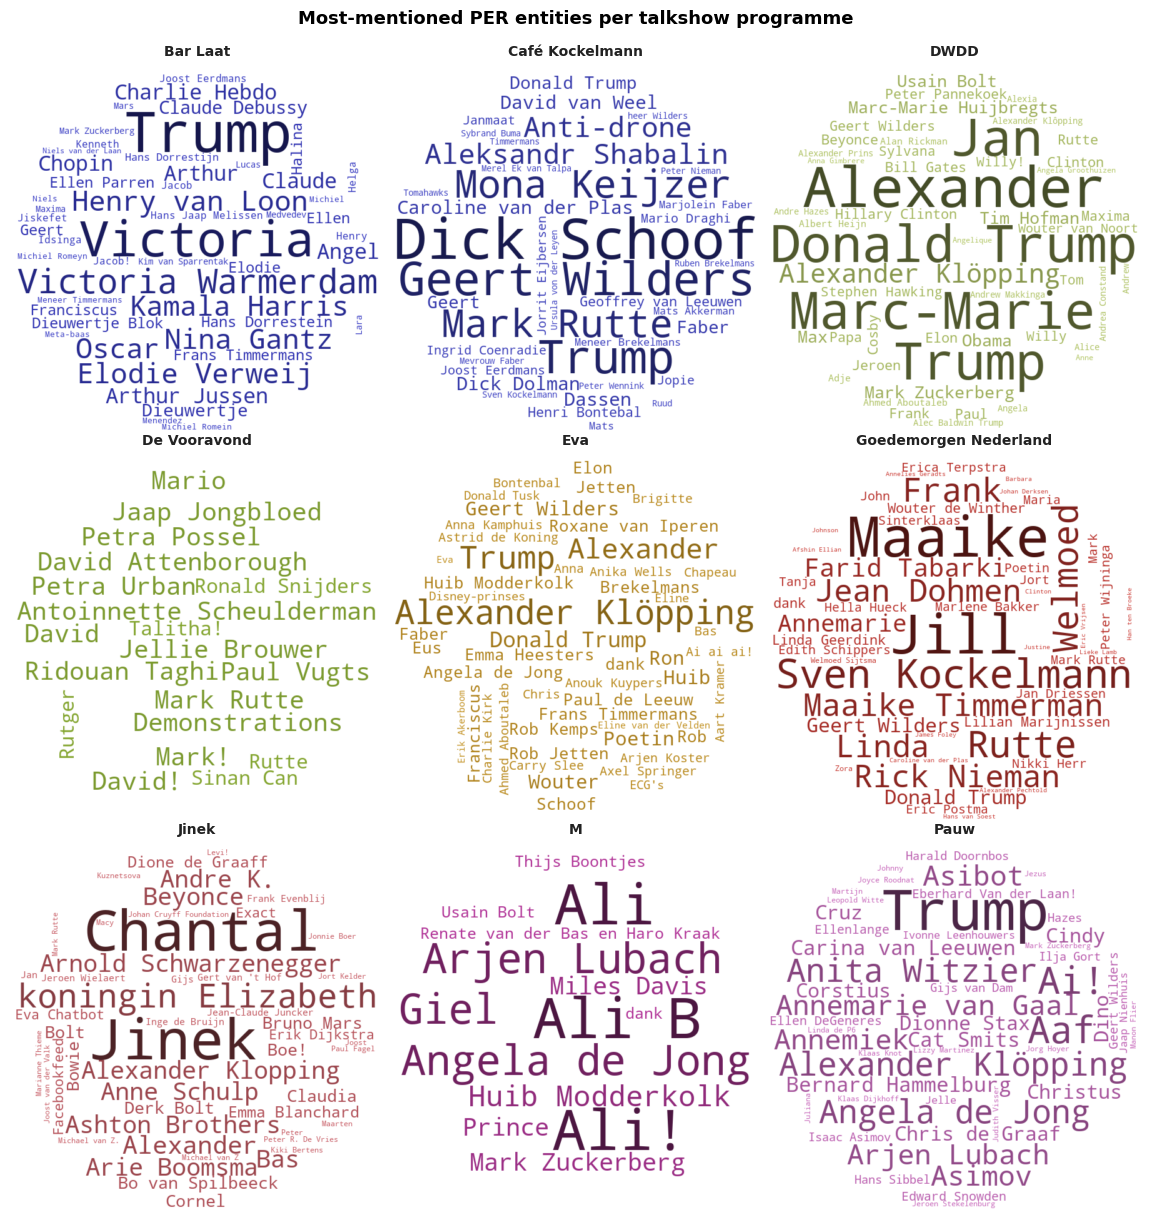

Saved → wordclouds_talkshows_per.png


In [42]:
plot_wordclouds(
    subs_raw, "group",
    tint_map=prog_tints,
    ncols=3,
    title=f"Most-mentioned {ENTITY_TYPE} entities per talkshow programme",
    out_path=OUT_SUBS,
)


## Step 7 — Summary: top entities for TK types and talkshows

In [43]:
print("=" * 52)
print(f"TOP ENTITIES PER TK DOCUMENT TYPE  (type={ENTITY_TYPE})")
print("=" * 52)
top_entities_table(tk_counts, "group", n=8)

print()
print("=" * 52)
print(f"TOP ENTITIES PER TALKSHOW  (type={ENTITY_TYPE})")
print("=" * 52)
top_entities_table(subs_raw, "group", n=8)


TOP ENTITIES PER TK DOCUMENT TYPE  (type=PER)
────────────────────────────────────────────────
  beleidsnota
             entity  count
1      Six Dijkstra     17
2  Dekker-Abdulaziz     12
3          Kathmann     12
4      Parafenroute     11
5               J V      7
6       Telecomraad      6
7  algoritmegebruik      6
8     verzamelbrief      6
────────────────────────────────────────────────
  plenair verslag
            entity  count
1   heer Verhoeven     30
2     heer Wilders     24
3  heer Paternotte     23
4  heer Van Baarle     23
5       Van Baarle     19
6             dank     19
7  VVD):Voorzitter     17
8  Jasper van Dijk     16
────────────────────────────────────────────────
  vergaderstuk
                 entity  count
1       BegeleidingsCie      4
2             Parallel/      4
3                TPSP's      4
4  sustainability Allen      4
5                   e m      3
6                   AVG      2
7             Financién      2
8          Six Dijkstra      2
────